In [1]:
import hoda
import tensorly as tl
import mne
%load_ext autoreload
%autoreload 2

!pip install line_profiler
%load_ext line_profiler


#tl.tenalg.set_backend('einsum')
#tl.plugins.use_opt_einsum()
    
mne.set_log_level('ERROR')
print(tl.get_backend())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload

[notice] A new release of pip is available: 23.2.1 -> 24.1
[notice] To update, run: python3 -m pip install --upgrade pip
The line_profiler extension is already loaded. To reload it, use:
  %reload_ext line_profiler
cupy


In [2]:
%env TENSORLY_BACKEND

'cupy'

In [3]:
from moabb.paradigms import P300, LeftRightImagery
from moabb.datasets import *
from mne.decoding import Scaler


#paradigm = P300(resample=48)
#dataset = BI2013a()
#dataset = BNCI2014_008()
sfreq=500
paradigm=LeftRightImagery(resample=sfreq)
dataset = BNCI2014_004()
epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[2],
     return_epochs=True
)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [4]:
meta

,subject,session,run
0,2,0train,0
1,2,0train,0
2,2,0train,0
3,2,0train,0
4,2,0train,0
...,...,...,...
115,2,0train,0
116,2,0train,0
117,2,0train,0
118,2,0train,0


In [5]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
import numpy as np
from sklearn.model_selection import train_test_split
from hoda.tensorize import stf_tensor

X = epochs.get_data()
X = stf_tensor(X, sfreq=sfreq, zscore=False, morlet_params=dict(n_jobs=-1))
X = tl.tensor(X)
y = labels


print(X.shape)
print(X.dtype)

(120, 3, 23, 112)
float32


In [ ]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, GreedyBTTDA, HODA, trunc_eigh
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler


bttda = GreedyBTTDA(
    max_blocks=2,
    truncate=True,
    rank_grid=[1,2,3],
    #rank_grid=None,
    hoda_params=dict(
        rank=None,
        max_iter=64,
        tol=1e-8,
        init ='eye',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',
        taper=False,
        extra_train_info=False,
        verbose=False,
        random_state=42,
        delta=None,       
    ),
    verbose=True,
    extra_train_info=True,
    cv=StratifiedKFold(random_state=42, shuffle=True),
    n_jobs=1,
    
)
%time bttda.fit(X,y)

Model selection block 1/2...
Fitting 5 folds for each of 3 candidates, totalling 15 fits


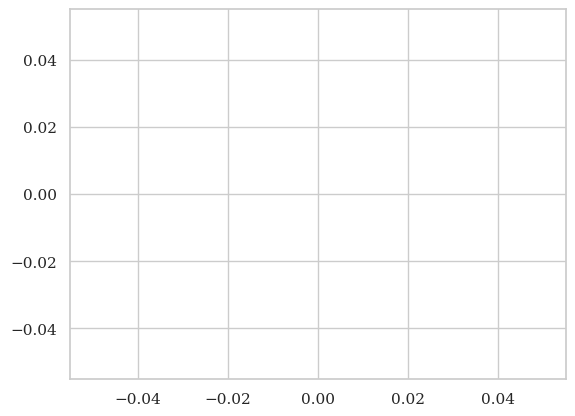

In [7]:
plt.plot(bttda.val_scores_)

In [8]:
import pandas as pd

df = pd.DataFrame(bttda.train_info_)
df

AttributeError: 'GreedyBTTDA' object has no attribute 'train_info_'

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')
import pandas as pd
df = pd.DataFrame(bttda.train_info_)
df
if bttda.extra_train_info:
    n_samples = X.shape[0]
    sns.lineplot(data=df, x='block', y='nmse')
    plt.show()
    sns.lineplot(data=df,x='block',y='F_rt')

In [ ]:
Xt = bttda.transform(X)
Xt_flat = tl.to_numpy(Xt)

In [ ]:
import scipy.stats
import seaborn as sns
import math
import numpy as np

samples = []
for c in bttda.blocks_[0].classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
F = F.flatten()
p = p.flatten()
p = np.nan_to_num(p, nan=1)
fig, ax = plt.subplots(1,1)
sig_idc = p < 0.05
plt.bar(np.arange(len(F))[sig_idc],F[sig_idc], color='blue')
plt.bar(np.arange(len(F))[~sig_idc],F[~sig_idc], color='red')
plt.yscale('log')
n_params=0
plt.axvline(n_params-.5, color='black')
for b,block in enumerate(bttda.blocks_):
    n_params+=math.prod(block.rank_)
    plt.axvline(n_params-.5, color='black')

In [ ]:
sns.heatmap(np.corrcoef(Xt_flat, rowvar=False),  cmap='vlag', center=0)

In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns
from matplotlib import pyplot as plt

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(Xt_flat)
    df = pd.DataFrame(Xt_viz, columns=['PC1', 'PC2'])
    df['label'] = y
    df=df.reset_index()
    print(df)
    sns.scatterplot(data=df, x='PC1', y='PC2', hue='label',)
    sns.kdeplot(data=df, x='PC1', y='PC2', hue='label',)
    ax = plt.gca()    
    ax.spines['bottom'].set_position('zero')
    ax.spines['left'].set_position('zero')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)